# HW #5 — AlexNet-like CNN on CIFAR-10
**Course:** Deep Learning for Computer Vision (EN525.733.8VL)  
**Due Date:** March 12, 2026  
**Samih Amer**

---

## Assignment Overview

In this assignment we build an **AlexNet-like convolutional neural network** for 10-class image classification on the CIFAR-10 dataset (32x32 color images). We then perform **ablation studies** by removing individual layers to understand how each layer contributes to classification performance.

### Tasks
1. **Experiment 1 (Baseline):** Train the full AlexNet-like network as specified in the diagram. Plot learning curves, classification accuracy, and confusion matrix.
2. **Experiment 2:** Remove **Layer 5** (Conv-256 + MaxPool). Retrain and evaluate.
3. **Experiment 3:** Remove **Layer 4** (Conv-192). Retrain and evaluate.
4. **Experiment 4:** Remove **FC Layer 6** (FC-512). Retrain and evaluate.

### Network Architecture (Full Model — Bottom to Top)

| Layer | Type | Kernels / Neurons | Kernel Size | Output Size | Notes |
|-------|------|-------------------|-------------|-------------|-------|
| Input | — | — | — | 32x32x3 | CIFAR-10 RGB image |
| **Layer 1** | Conv + ReLU + MaxPool | 48 | 3x3 | 16x16x48 | Pool 2x2, stride 2 |
| **Layer 2** | Conv + ReLU + MaxPool | 96 | 3x3 | 8x8x96 | Pool 2x2, stride 2 |
| **Layer 3** | Conv + ReLU | 192 | 3x3 | 8x8x192 | No pooling |
| **Layer 4** | Conv + ReLU | 192 | 3x3 | 8x8x192 | No pooling |
| **Layer 5** | Conv + ReLU + MaxPool | 256 | 3x3 | 4x4x256 | Pool 2x2, stride 2 |
| **Layer 6** | FC + ReLU | 512 | — | 512 | Fully connected |
| **Layer 7** | FC + ReLU | 256 | — | 256 | Fully connected |
| **Output** | FC + Softmax | 10 | — | 10 | 10-way classification |

### Hyperparameters Summary

| Hyperparameter | Value | Rationale |
|---|---|---|
| **Optimizer** | Adam | Adaptive learning rate; converges reliably on CIFAR-10 |
| **Learning rate** | 0.001 | Standard Adam default; good starting point for CNNs |
| **Batch size** | 128 | Balance between GPU memory utilization and gradient stability |
| **Epochs** | 30 | Sufficient for convergence on CIFAR-10 with this architecture |
| **Loss function** | CrossEntropyLoss | Standard for multi-class classification; includes softmax internally |
| **Activation** | ReLU | Standard for CNNs; avoids vanishing gradient, fast to compute |
| **Padding** | 1 (all conv layers) | Preserves spatial dimensions through convolution (same padding) |
| **Pool size** | 2x2, stride 2 | Halves spatial dimensions at each pooling stage |
| **Dropout** | 0.5 (FC layers) | Regularization to prevent overfitting in the fully-connected layers |
| **Data augmentation** | Random horizontal flip + random crop with padding | Standard CIFAR-10 augmentation to improve generalization |
| **Framework** | PyTorch | Deep learning library for model definition, training, and GPU acceleration |

## 1. Imports and Setup

We use **PyTorch** as our deep learning framework. Key packages:
- `torch.nn` — defines convolutional layers (Conv2d), pooling (MaxPool2d), fully-connected layers (Linear), and loss (CrossEntropyLoss)
- `torch.optim` — provides the Adam optimizer
- `torchvision.transforms` — data augmentation and normalization transforms
- `sklearn.metrics` — confusion matrix computation
- `matplotlib` / `seaborn` — for generating all plots

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load CIFAR-10 Data

The CIFAR-10 dataset is stored as Python pickle files. Each batch file contains a dictionary with:
- `data` — a 10000x3072 numpy array of uint8. Each row is a 32x32 colour image (3072 = 3 channels x 32 x 32). The first 1024 entries are red, next 1024 green, last 1024 blue.
- `labels` — a list of 10000 integers (0–9) giving the class of each image.

We load all 5 training batches (50,000 images) and the test batch (10,000 images), then reshape to `(N, 3, 32, 32)` format for PyTorch convolutions.

**Normalization:** We normalize pixel values to [0, 1] by dividing by 255. We then apply **per-channel normalization** using the CIFAR-10 training set mean and standard deviation. This centers each channel around zero and scales to unit variance, which helps the optimizer converge faster.

**Data augmentation** (training only):
- **Random horizontal flip** — CIFAR-10 objects can appear facing either direction
- **Random crop with 4-pixel padding** — shifts the image slightly, forcing the network to learn translation-invariant features

In [3]:
def unpickle(file):
    """Load a CIFAR-10 batch file."""
    with open(file, 'rb') as f:
        data_dict = pickle.load(f, encoding='bytes')
    return data_dict

# Path to the CIFAR-10 data
DATA_DIR = "cifar-10-python/cifar-10-batches-py"

# Load training data (5 batches)
train_images_list = []
train_labels_list = []
for i in range(1, 6):
    batch = unpickle(os.path.join(DATA_DIR, f"data_batch_{i}"))
    train_images_list.append(batch[b'data'])
    train_labels_list.extend(batch[b'labels'])

train_images = np.concatenate(train_images_list, axis=0)  # (50000, 3072)
train_labels = np.array(train_labels_list, dtype=np.int64)

# Load test data
test_batch = unpickle(os.path.join(DATA_DIR, "test_batch"))
test_images = test_batch[b'data']                          # (10000, 3072)
test_labels = np.array(test_batch[b'labels'], dtype=np.int64)

# Load class names
meta = unpickle(os.path.join(DATA_DIR, "batches.meta"))
class_names = [name.decode('utf-8') for name in meta[b'label_names']]

# Reshape to (N, 3, 32, 32) and normalize to [0, 1]
train_images = train_images.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
test_images  = test_images.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0

# Compute per-channel mean and std from training set for normalization
channel_mean = train_images.mean(axis=(0, 2, 3))  # shape: (3,)
channel_std  = train_images.std(axis=(0, 2, 3))    # shape: (3,)

print(f"Channel means (R, G, B): {channel_mean}")
print(f"Channel stds  (R, G, B): {channel_std}")

# Normalize both sets using training statistics
for c in range(3):
    train_images[:, c, :, :] = (train_images[:, c, :, :] - channel_mean[c]) / channel_std[c]
    test_images[:, c, :, :]  = (test_images[:, c, :, :]  - channel_mean[c]) / channel_std[c]

print(f"\nTraining set: {train_images.shape[0]:,} images, shape {train_images.shape[1:]}")
print(f"Test set:     {test_images.shape[0]:,} images")
print(f"Classes:      {class_names}")

Channel means (R, G, B): [0.4914009  0.48215896 0.4465308 ]
Channel stds  (R, G, B): [0.24703279 0.24348423 0.26158753]

Training set: 50,000 images, shape (3, 32, 32)
Test set:     10,000 images
Classes:      ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Data Augmentation and DataLoaders

We apply **data augmentation** only to the training set to improve generalization:

- **Random horizontal flip (p=0.5):** CIFAR-10 images of cars, planes, etc. look equally valid when mirrored. This effectively doubles the diversity of training data without additional storage.
- **Random crop with 4-pixel padding:** We pad the 32x32 image by 4 pixels on each side (to 40x40), then randomly crop back to 32x32. This simulates small translations, making the model robust to slight positional shifts of objects.

The test set receives **no augmentation** — we evaluate on the original images to get a consistent accuracy measurement.

**Batch size = 128** provides good GPU utilization while maintaining stable gradient estimates.

In [4]:
import torch.nn.functional as F

BATCH_SIZE = 128
NUM_EPOCHS = 30

class CIFAR10Dataset(torch.utils.data.Dataset):
    """Custom dataset that applies data augmentation on-the-fly."""
    def __init__(self, images, labels, augment=False):
        self.images = torch.from_numpy(images)
        self.labels = torch.from_numpy(labels)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.augment:
            # Random horizontal flip with probability 0.5
            if torch.rand(1).item() > 0.5:
                img = torch.flip(img, dims=[2])
            # Random crop with 4-pixel padding
            img = F.pad(img, (4, 4, 4, 4), mode='reflect')
            i = torch.randint(0, 8, (1,)).item()
            j = torch.randint(0, 8, (1,)).item()
            img = img[:, i:i+32, j:j+32]
        return img, label

train_dataset = CIFAR10Dataset(train_images, train_labels, augment=True)
test_dataset  = CIFAR10Dataset(test_images,  test_labels,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(device.type == "cuda"))

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 128
Training batches per epoch: 391
Test batches: 79


## 4. Model Architectures

We define **four variants** of the AlexNet-like CNN. All share the same design pattern but differ in which layers are included:

### Full Model (Experiment 1)
The complete architecture as shown in the assignment diagram:
```
Input(3x32x32) -> Conv1(48)+Pool -> Conv2(96)+Pool -> Conv3(192) -> Conv4(192) -> Conv5(256)+Pool -> FC(512) -> FC(256) -> Output(10)
```

### Variant 2: No Layer 5 (Experiment 2)
Removes Conv5 (256 kernels) and its associated max-pooling. The feature maps from Layer 4 (8x8x192) are flattened directly and fed to the FC layers. This tests the importance of the deepest convolutional layer.

### Variant 3: No Layer 4 (Experiment 3)
Removes Conv4 (192 kernels). Layer 3 output (8x8x192) feeds directly into Layer 5. Since both Layer 3 output and Layer 4 output have the same number of channels (192), Layer 5's input dimensions remain unchanged.

### Variant 4: No FC Layer 6 (Experiment 4)
Removes the FC-512 layer. The flattened conv features connect directly to FC-256 (Layer 7). This tests whether the extra fully-connected capacity is necessary.

**Design choices:**
- **ReLU activation** after every conv and FC layer (except output) — standard for CNNs, avoids vanishing gradients
- **Batch Normalization** after each conv layer — stabilizes training, allows higher learning rates
- **Dropout (0.5)** on FC layers — prevents overfitting by randomly zeroing half the activations during training
- **Padding = 1** on all 3x3 convolutions — preserves spatial dimensions through convolution (only pooling reduces size)

In [5]:
class AlexNetLike_Full(nn.Module):
    """
    Full AlexNet-like architecture for CIFAR-10 (32x32 input).
    
    Architecture:
        Layer 1: Conv(3->48, 3x3, pad=1) + BN + ReLU + MaxPool(2x2)   -> 16x16x48
        Layer 2: Conv(48->96, 3x3, pad=1) + BN + ReLU + MaxPool(2x2)  -> 8x8x96
        Layer 3: Conv(96->192, 3x3, pad=1) + BN + ReLU                -> 8x8x192
        Layer 4: Conv(192->192, 3x3, pad=1) + BN + ReLU               -> 8x8x192
        Layer 5: Conv(192->256, 3x3, pad=1) + BN + ReLU + MaxPool(2x2)-> 4x4x256
        Flatten: 4*4*256 = 4096
        Layer 6: FC(4096->512) + ReLU + Dropout(0.5)
        Layer 7: FC(512->256) + ReLU + Dropout(0.5)
        Output:  FC(256->10)
    """
    def __init__(self):
        super().__init__()
        # Convolutional layers
        self.features = nn.Sequential(
            # Layer 1: Conv + Pool -> 32x32 -> 16x16
            nn.Conv2d(3, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 2: Conv + Pool -> 16x16 -> 8x8
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 3: Conv (no pool) -> 8x8
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            # Layer 4: Conv (no pool) -> 8x8
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            # Layer 5: Conv + Pool -> 8x8 -> 4x4
            nn.Conv2d(192, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),   # Layer 6
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),            # Layer 7
            nn.ReLU(inplace=True),
            nn.Linear(256, 10),             # Output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x


class AlexNetLike_NoLayer5(nn.Module):
    """
    AlexNet-like with Layer 5 (Conv-256 + MaxPool) REMOVED.
    
    After Layer 4, feature maps are 8x8x192 (no further pooling).
    Flatten: 8*8*192 = 12288 -> FC layers.
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 2
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 3
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            # Layer 4
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            # Layer 5 REMOVED
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(192 * 8 * 8, 512),   # Layer 6 (input from 8x8x192)
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),            # Layer 7
            nn.ReLU(inplace=True),
            nn.Linear(256, 10),             # Output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


class AlexNetLike_NoLayer4(nn.Module):
    """
    AlexNet-like with Layer 4 (Conv-192) REMOVED.
    
    Layer 3 output (8x8x192) feeds directly into Layer 5 (Conv-256).
    Layer 5 expects 192 input channels — same as original, so dimensions match.
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 2
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 3
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            # Layer 4 REMOVED
            # Layer 5: Conv + Pool -> 8x8 -> 4x4
            nn.Conv2d(192, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),   # Layer 6
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),            # Layer 7
            nn.ReLU(inplace=True),
            nn.Linear(256, 10),             # Output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


class AlexNetLike_NoFC6(nn.Module):
    """
    AlexNet-like with FC Layer 6 (FC-512) REMOVED.
    
    Flattened conv features (4*4*256 = 4096) connect directly to FC-256 (Layer 7).
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 2
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Layer 3
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            # Layer 4
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            # Layer 5
            nn.Conv2d(192, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            # Layer 6 REMOVED
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 256),   # Layer 7 (directly from flattened features)
            nn.ReLU(inplace=True),
            nn.Linear(256, 10),             # Output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# Print parameter counts for all models
models_info = {
    "Exp 1: Full Model": AlexNetLike_Full(),
    "Exp 2: No Layer 5": AlexNetLike_NoLayer5(),
    "Exp 3: No Layer 4": AlexNetLike_NoLayer4(),
    "Exp 4: No FC Layer 6": AlexNetLike_NoFC6(),
}

print(f"{'Model':<25} {'Parameters':>12}")
print("-" * 40)
for name, model in models_info.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name:<25} {n_params:>12,}")
del models_info

Model                       Parameters
----------------------------------------
Exp 1: Full Model            3,216,714
Exp 2: No Layer 5            6,967,882
Exp 3: No Layer 4            2,884,362
Exp 4: No FC Layer 6         2,036,554


## 5. Training & Evaluation Functions

### Training Loop
For each epoch:
1. **Forward pass:** Feed a batch of images through the CNN to get class logits
2. **Compute loss:** CrossEntropyLoss between predicted logits and true labels (includes softmax internally)
3. **Backward pass:** Compute gradients via backpropagation
4. **Update weights:** Adam optimizer adjusts all parameters
5. **Evaluate:** Compute loss and accuracy on the test set (no gradient computation for efficiency)

### Loss Function: CrossEntropyLoss
$$\text{CE} = -\frac{1}{N}\sum_{i=1}^{N} \log\left(\frac{e^{z_{y_i}}}{\sum_j e^{z_j}}\right)$$

Where $z$ are the raw logits and $y_i$ is the true class. This combines log-softmax and negative log-likelihood — the standard loss for multi-class classification.

### Plotting Utilities
For each experiment, we generate:
1. **Learning curves** — training loss and test loss vs. epoch, plus training accuracy and test accuracy vs. epoch
2. **Confusion matrix** — a 10x10 heatmap showing per-class predictions vs. ground truth
3. **Classification report** — per-class precision, recall, and F1-score

In [6]:
def evaluate(model, loader, criterion):
    """Compute loss and accuracy on a dataset (no gradient computation)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / total, 100.0 * correct / total


def get_predictions(model, loader):
    """Get all predictions and true labels from a dataset."""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def train_model(model, model_name, num_epochs=NUM_EPOCHS, lr=1e-3):
    """
    Train a model and return per-epoch loss/accuracy histories.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    print(f"\n{'='*65}")
    print(f"Training: {model_name}")
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {n_params:,} | Optimizer: Adam | LR: {lr}")
    print(f"Epochs: {num_epochs} | Batch size: {BATCH_SIZE}")
    print(f"{'='*65}")

    for epoch in range(1, num_epochs + 1):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100.0 * correct / total

        # --- Test evaluation ---
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    print(f"\n  Final Test Accuracy: {test_accs[-1]:.2f}%")

    history = {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
    }
    return model, history


def plot_learning_curves(history, title):
    """Plot loss and accuracy learning curves side by side."""
    epochs = range(1, len(history['train_losses']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    ax1.plot(epochs, history['train_losses'], 'b-', linewidth=1.8, label='Train Loss')
    ax1.plot(epochs, history['test_losses'], 'r--', linewidth=1.8, label='Test Loss')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Cross-Entropy Loss', fontsize=11)
    ax1.set_title(f'{title} — Loss vs. Epoch', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Accuracy curves
    ax2.plot(epochs, history['train_accs'], 'b-', linewidth=1.8, label='Train Accuracy')
    ax2.plot(epochs, history['test_accs'], 'r--', linewidth=1.8, label='Test Accuracy')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Accuracy (%)', fontsize=11)
    ax2.set_title(f'{title} — Accuracy vs. Epoch', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, loader, title):
    """Generate and plot confusion matrix + print classification report."""
    preds, labels = get_predictions(model, loader)
    cm = confusion_matrix(labels, preds)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"\nClassification Report — {title}")
    print("=" * 65)
    print(classification_report(labels, preds, target_names=class_names, digits=4))

    overall_acc = 100.0 * np.sum(preds == labels) / len(labels)
    print(f"Overall Test Accuracy: {overall_acc:.2f}%")
    return overall_acc


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


---

## 6. Experiment 1 — Full AlexNet-like Model (Baseline)

This is the **complete architecture** as specified in the assignment diagram. All 5 convolutional layers + 2 FC layers are present.

**Expected behavior:** This should achieve the best performance among all variants since it has the most capacity (both in terms of convolutional depth and FC layer width). Typical CIFAR-10 accuracy for this class of architecture is in the range of ~82–88%.

In [7]:
# Experiment 1: Full Model
model_1 = AlexNetLike_Full()
model_1, history_1 = train_model(model_1, "Exp 1: Full AlexNet-like Model")


Training: Exp 1: Full AlexNet-like Model
Parameters: 3,216,714 | Optimizer: Adam | LR: 0.001
Epochs: 30 | Batch size: 128
  Epoch   1/30 | Train Loss: 1.4964 | Train Acc: 44.43% | Test Loss: 1.2778 | Test Acc: 54.11%
  Epoch   5/30 | Train Loss: 0.7769 | Train Acc: 73.29% | Test Loss: 0.6724 | Test Acc: 76.78%
  Epoch  10/30 | Train Loss: 0.5552 | Train Acc: 81.42% | Test Loss: 0.5175 | Test Acc: 82.49%
  Epoch  15/30 | Train Loss: 0.4429 | Train Acc: 85.23% | Test Loss: 0.5075 | Test Acc: 82.78%
  Epoch  20/30 | Train Loss: 0.3624 | Train Acc: 88.00% | Test Loss: 0.4270 | Test Acc: 85.88%
  Epoch  25/30 | Train Loss: 0.3074 | Train Acc: 89.84% | Test Loss: 0.4289 | Test Acc: 85.67%
  Epoch  30/30 | Train Loss: 0.2629 | Train Acc: 91.15% | Test Loss: 0.3760 | Test Acc: 87.56%

  Final Test Accuracy: 87.56%


### Experiment 1 — Learning Curves

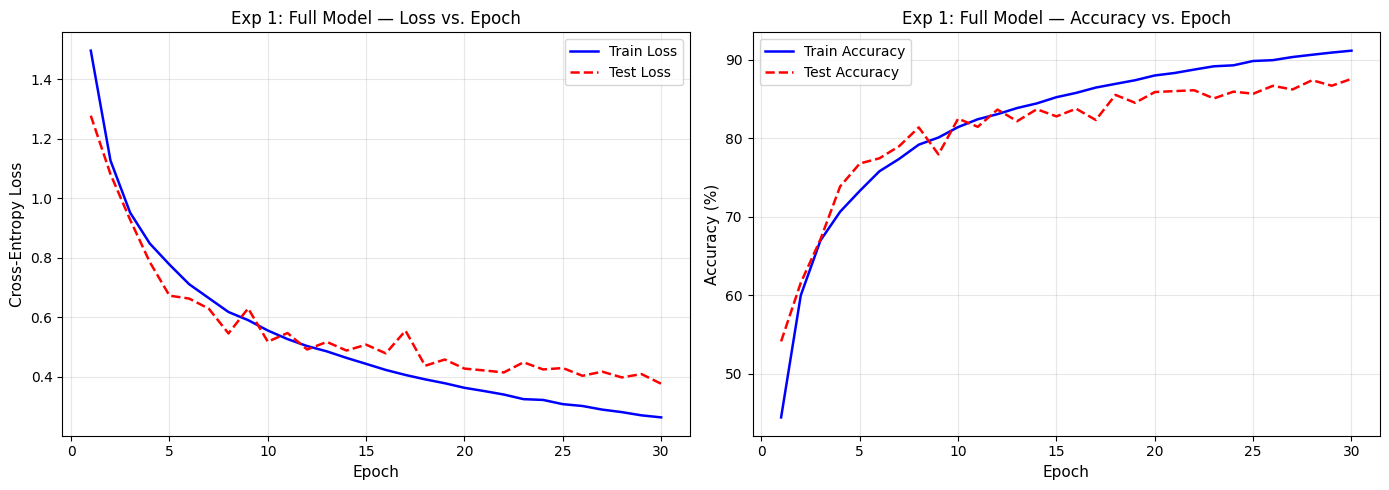

In [8]:
plot_learning_curves(history_1, "Exp 1: Full Model")

### Experiment 1 — Confusion Matrix & Classification Report

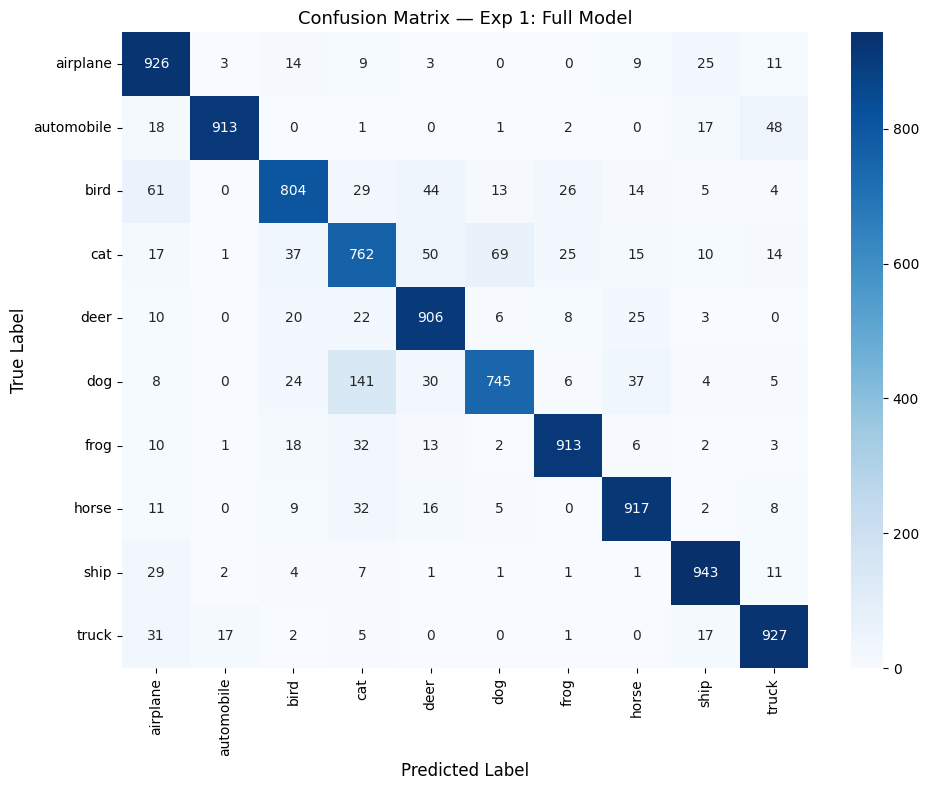


Classification Report — Exp 1: Full Model
              precision    recall  f1-score   support

    airplane     0.8260    0.9260    0.8732      1000
  automobile     0.9744    0.9130    0.9427      1000
        bird     0.8627    0.8040    0.8323      1000
         cat     0.7327    0.7620    0.7471      1000
        deer     0.8523    0.9060    0.8783      1000
         dog     0.8848    0.7450    0.8089      1000
        frog     0.9297    0.9130    0.9213      1000
       horse     0.8955    0.9170    0.9061      1000
        ship     0.9173    0.9430    0.9300      1000
       truck     0.8991    0.9270    0.9129      1000

    accuracy                         0.8756     10000
   macro avg     0.8775    0.8756    0.8753     10000
weighted avg     0.8775    0.8756    0.8753     10000

Overall Test Accuracy: 87.56%


In [9]:
acc_1 = plot_confusion_matrix(model_1, test_loader, "Exp 1: Full Model")

---

## 7. Experiment 2 — Remove Layer 5 (Conv-256 + MaxPool)

In this experiment we **delete Layer 5** — the deepest convolutional layer (256 kernels, 3x3) and its associated max-pooling.

**What changes:**
- The feature extractor ends at Layer 4, producing 8x8x192 feature maps
- Without the Layer 5 max-pool, spatial resolution stays at 8x8 (instead of being reduced to 4x4)
- The flattened feature vector is 8x8x192 = **12,288** dimensions (vs. 4x4x256 = 4,096 in the full model)
- FC Layer 6 input size increases from 4,096 to 12,288

**Expected impact:**
- Removing the deepest conv layer reduces the network's ability to learn complex, high-level feature combinations
- The larger flattened representation (12,288 vs 4,096) puts more burden on the FC layers
- We expect a **moderate drop in accuracy** since Layer 5 provides important high-level feature abstraction

In [10]:
# Experiment 2: Remove Layer 5 (Conv-256 + MaxPool)
model_2 = AlexNetLike_NoLayer5()
model_2, history_2 = train_model(model_2, "Exp 2: No Layer 5 (Conv-256 + Pool)")


Training: Exp 2: No Layer 5 (Conv-256 + Pool)
Parameters: 6,967,882 | Optimizer: Adam | LR: 0.001
Epochs: 30 | Batch size: 128
  Epoch   1/30 | Train Loss: 1.4463 | Train Acc: 47.20% | Test Loss: 1.1526 | Test Acc: 58.04%
  Epoch   5/30 | Train Loss: 0.7844 | Train Acc: 72.83% | Test Loss: 0.7341 | Test Acc: 74.68%
  Epoch  10/30 | Train Loss: 0.6018 | Train Acc: 79.49% | Test Loss: 0.5769 | Test Acc: 79.28%
  Epoch  15/30 | Train Loss: 0.4913 | Train Acc: 83.36% | Test Loss: 0.5494 | Test Acc: 80.87%
  Epoch  20/30 | Train Loss: 0.4293 | Train Acc: 85.55% | Test Loss: 0.4503 | Test Acc: 84.77%
  Epoch  25/30 | Train Loss: 0.3728 | Train Acc: 87.41% | Test Loss: 0.4270 | Test Acc: 85.54%
  Epoch  30/30 | Train Loss: 0.3400 | Train Acc: 88.57% | Test Loss: 0.4132 | Test Acc: 86.04%

  Final Test Accuracy: 86.04%


### Experiment 2 — Learning Curves

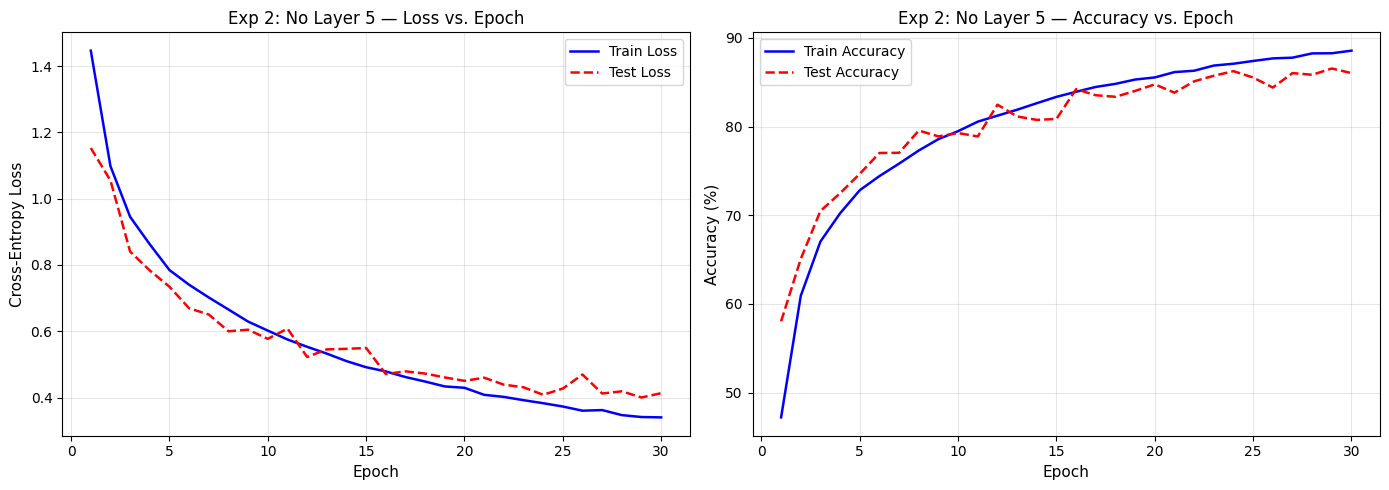

In [11]:
plot_learning_curves(history_2, "Exp 2: No Layer 5")

### Experiment 2 — Confusion Matrix & Classification Report

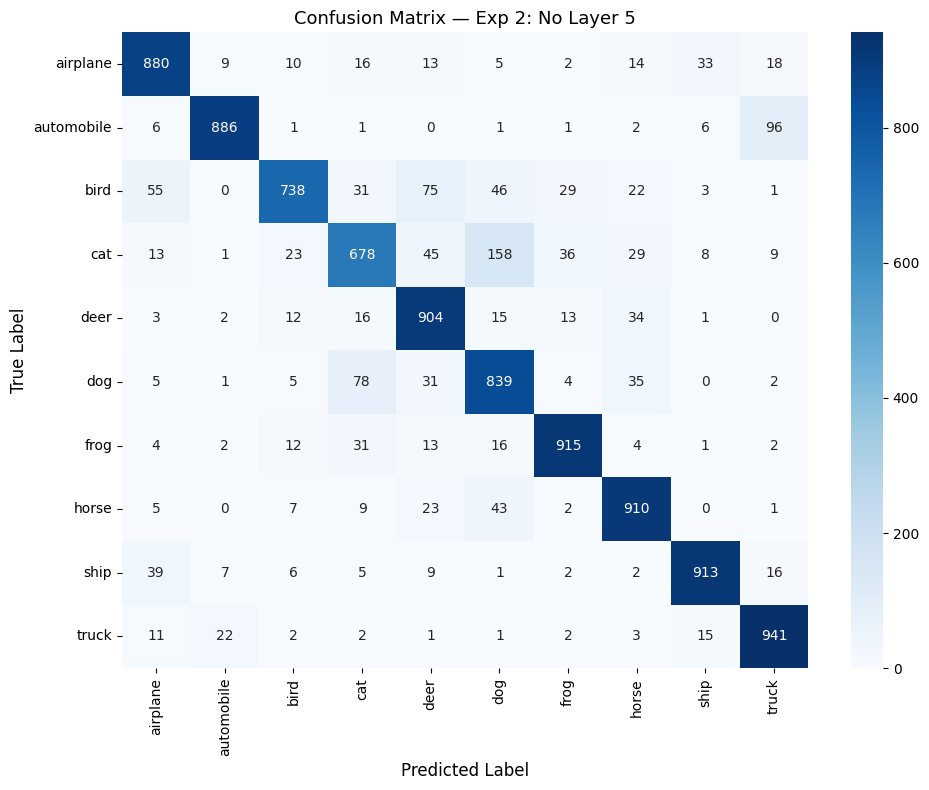


Classification Report — Exp 2: No Layer 5
              precision    recall  f1-score   support

    airplane     0.8619    0.8800    0.8709      1000
  automobile     0.9527    0.8860    0.9181      1000
        bird     0.9044    0.7380    0.8128      1000
         cat     0.7820    0.6780    0.7263      1000
        deer     0.8115    0.9040    0.8553      1000
         dog     0.7458    0.8390    0.7896      1000
        frog     0.9095    0.9150    0.9123      1000
       horse     0.8626    0.9100    0.8856      1000
        ship     0.9316    0.9130    0.9222      1000
       truck     0.8665    0.9410    0.9022      1000

    accuracy                         0.8604     10000
   macro avg     0.8628    0.8604    0.8595     10000
weighted avg     0.8628    0.8604    0.8595     10000

Overall Test Accuracy: 86.04%


In [12]:
acc_2 = plot_confusion_matrix(model_2, test_loader, "Exp 2: No Layer 5")

---

## 8. Experiment 3 — Remove Layer 4 (Conv-192)

In this experiment we **delete Layer 4** — the second Conv-192 layer (192 kernels, 3x3x192).

**What changes:**
- Layer 3 output (8x8x192) feeds directly into Layer 5 (Conv-256, 3x3x192)
- Since Layer 4's input and output both have 192 channels, removing it doesn't break any dimension compatibility — Layer 5 still receives 192-channel input
- The network loses one layer of convolutional depth but retains Layer 5's pooling

**Expected impact:**
- Layer 4 adds an extra round of nonlinear feature transformation at the same spatial resolution (8x8). Removing it reduces the network's representational capacity at that resolution.
- However, since Layer 4 doesn't perform pooling (it's a "same" conv layer), its removal is less disruptive than removing Layer 5 which also removes a pooling stage.
- We expect a **small-to-moderate drop in accuracy** — less impactful than removing Layer 5.

In [13]:
# Experiment 3: Remove Layer 4 (Conv-192)
model_3 = AlexNetLike_NoLayer4()
model_3, history_3 = train_model(model_3, "Exp 3: No Layer 4 (Conv-192)")


Training: Exp 3: No Layer 4 (Conv-192)
Parameters: 2,884,362 | Optimizer: Adam | LR: 0.001
Epochs: 30 | Batch size: 128
  Epoch   1/30 | Train Loss: 1.5017 | Train Acc: 44.29% | Test Loss: 1.3338 | Test Acc: 52.49%
  Epoch   5/30 | Train Loss: 0.8209 | Train Acc: 71.55% | Test Loss: 0.7617 | Test Acc: 74.35%
  Epoch  10/30 | Train Loss: 0.6253 | Train Acc: 78.78% | Test Loss: 0.5608 | Test Acc: 81.32%
  Epoch  15/30 | Train Loss: 0.5156 | Train Acc: 82.53% | Test Loss: 0.5308 | Test Acc: 81.85%
  Epoch  20/30 | Train Loss: 0.4450 | Train Acc: 84.88% | Test Loss: 0.4854 | Test Acc: 83.85%
  Epoch  25/30 | Train Loss: 0.3958 | Train Acc: 86.63% | Test Loss: 0.3994 | Test Acc: 86.68%
  Epoch  30/30 | Train Loss: 0.3556 | Train Acc: 88.01% | Test Loss: 0.4630 | Test Acc: 84.75%

  Final Test Accuracy: 84.75%


### Experiment 3 — Learning Curves

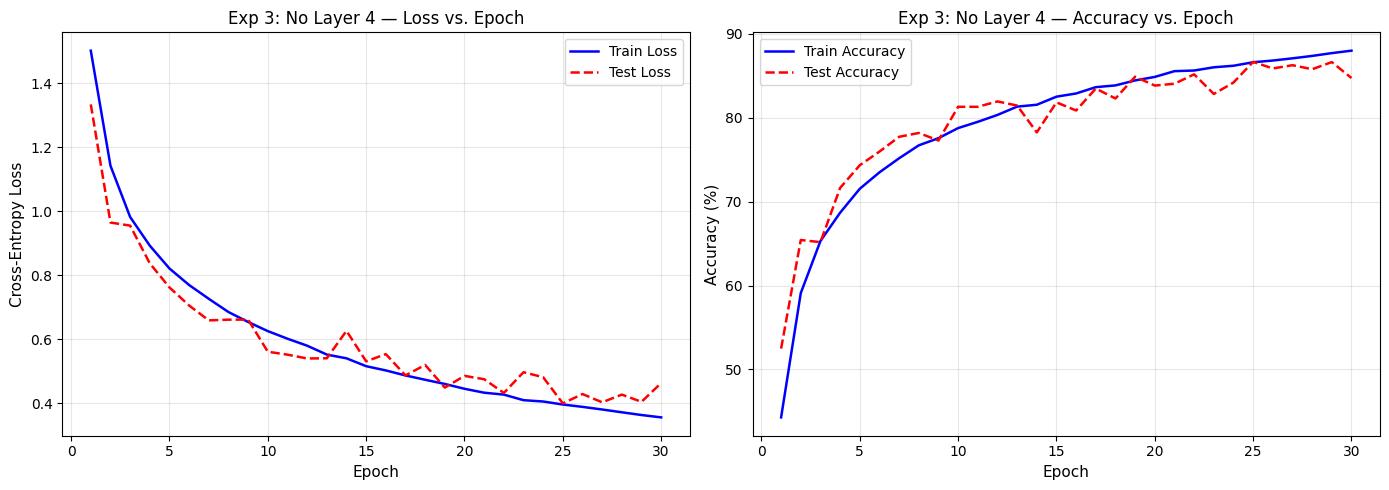

In [14]:
plot_learning_curves(history_3, "Exp 3: No Layer 4")

### Experiment 3 — Confusion Matrix & Classification Report

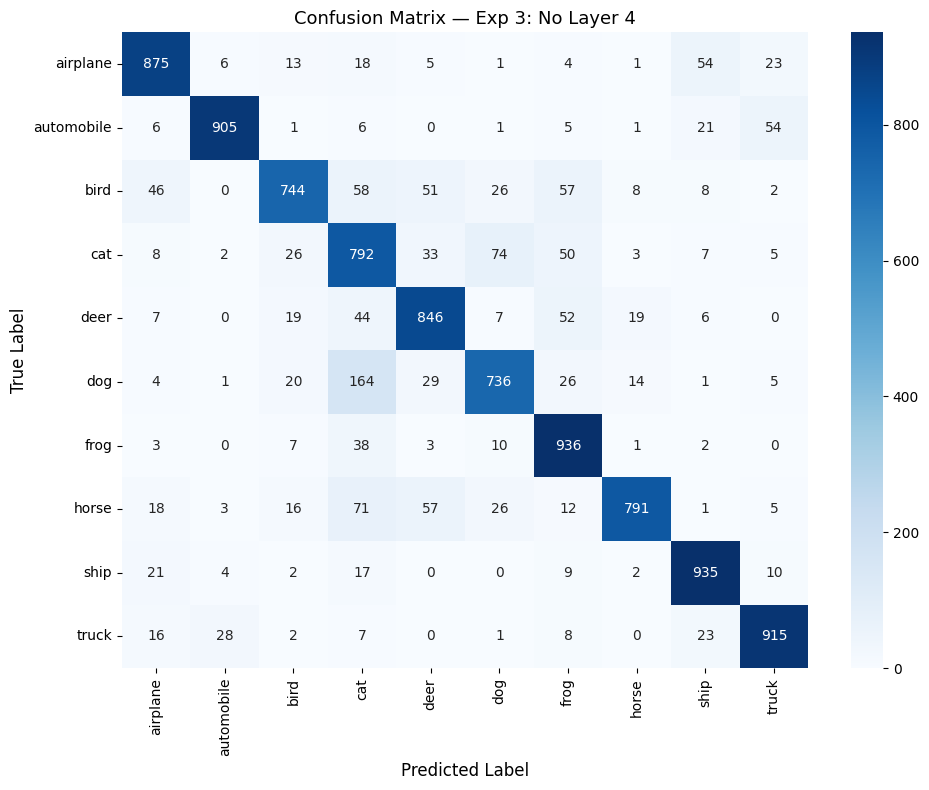


Classification Report — Exp 3: No Layer 4
              precision    recall  f1-score   support

    airplane     0.8715    0.8750    0.8733      1000
  automobile     0.9536    0.9050    0.9287      1000
        bird     0.8753    0.7440    0.8043      1000
         cat     0.6519    0.7920    0.7151      1000
        deer     0.8262    0.8460    0.8360      1000
         dog     0.8345    0.7360    0.7821      1000
        frog     0.8076    0.9360    0.8671      1000
       horse     0.9417    0.7910    0.8598      1000
        ship     0.8837    0.9350    0.9086      1000
       truck     0.8979    0.9150    0.9064      1000

    accuracy                         0.8475     10000
   macro avg     0.8544    0.8475    0.8481     10000
weighted avg     0.8544    0.8475    0.8481     10000

Overall Test Accuracy: 84.75%


In [15]:
acc_3 = plot_confusion_matrix(model_3, test_loader, "Exp 3: No Layer 4")

---

## 9. Experiment 4 — Remove FC Layer 6 (FC-512)

In this experiment we **delete FC Layer 6** — the first fully-connected layer with 512 neurons.

**What changes:**
- The flattened feature vector (4x4x256 = 4,096 dimensions) connects directly to FC-256 (Layer 7)
- This removes 4096x512 + 512 = **2,097,664 parameters** — a significant reduction since FC layers are the most parameter-heavy part of the network
- The classifier goes from a 2-layer MLP (4096->512->256->10) to a 1-layer MLP (4096->256->10)

**Expected impact:**
- FC layers provide the capacity to learn nonlinear decision boundaries from the extracted features
- Removing one FC layer reduces the classifier's expressiveness, but the convolutional features are still intact
- Since the conv layers do most of the heavy lifting for feature extraction, removing an FC layer may have **less impact than removing a conv layer**
- The reduction in parameters could also act as implicit regularization, potentially reducing overfitting

In [16]:
# Experiment 4: Remove FC Layer 6 (FC-512)
model_4 = AlexNetLike_NoFC6()
model_4, history_4 = train_model(model_4, "Exp 4: No FC Layer 6 (FC-512)")


Training: Exp 4: No FC Layer 6 (FC-512)
Parameters: 2,036,554 | Optimizer: Adam | LR: 0.001
Epochs: 30 | Batch size: 128
  Epoch   1/30 | Train Loss: 1.4431 | Train Acc: 46.80% | Test Loss: 1.2324 | Test Acc: 56.86%
  Epoch   5/30 | Train Loss: 0.6679 | Train Acc: 76.68% | Test Loss: 0.6337 | Test Acc: 78.09%
  Epoch  10/30 | Train Loss: 0.4692 | Train Acc: 83.88% | Test Loss: 0.5330 | Test Acc: 81.72%
  Epoch  15/30 | Train Loss: 0.3707 | Train Acc: 87.04% | Test Loss: 0.4672 | Test Acc: 84.50%
  Epoch  20/30 | Train Loss: 0.2985 | Train Acc: 89.65% | Test Loss: 0.5481 | Test Acc: 83.52%
  Epoch  25/30 | Train Loss: 0.2457 | Train Acc: 91.52% | Test Loss: 0.3885 | Test Acc: 87.32%
  Epoch  30/30 | Train Loss: 0.2040 | Train Acc: 92.87% | Test Loss: 0.4086 | Test Acc: 87.53%

  Final Test Accuracy: 87.53%


### Experiment 4 — Learning Curves

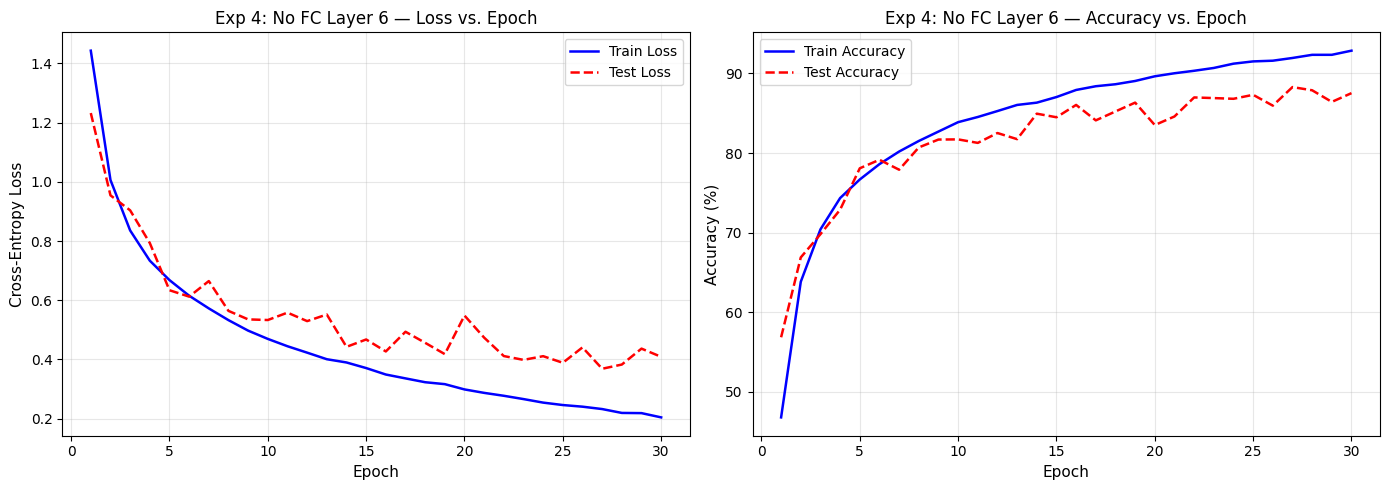

In [17]:
plot_learning_curves(history_4, "Exp 4: No FC Layer 6")

### Experiment 4 — Confusion Matrix & Classification Report

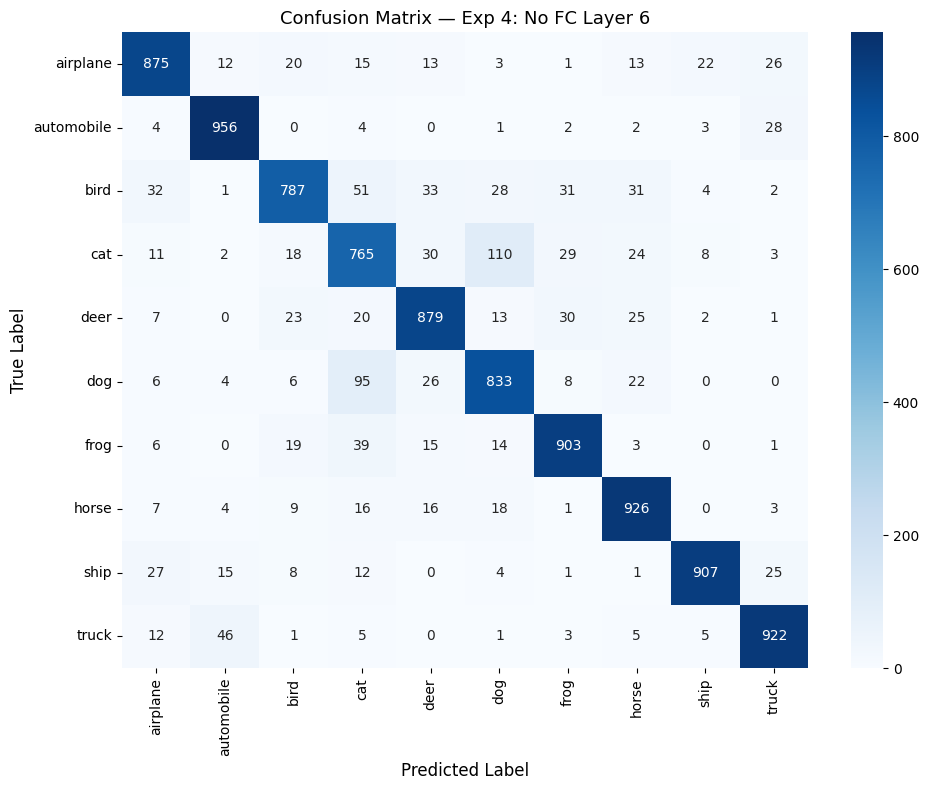


Classification Report — Exp 4: No FC Layer 6
              precision    recall  f1-score   support

    airplane     0.8865    0.8750    0.8807      1000
  automobile     0.9192    0.9560    0.9373      1000
        bird     0.8833    0.7870    0.8324      1000
         cat     0.7485    0.7650    0.7567      1000
        deer     0.8686    0.8790    0.8738      1000
         dog     0.8127    0.8330    0.8227      1000
        frog     0.8949    0.9030    0.8990      1000
       horse     0.8802    0.9260    0.9025      1000
        ship     0.9537    0.9070    0.9298      1000
       truck     0.9120    0.9220    0.9170      1000

    accuracy                         0.8753     10000
   macro avg     0.8760    0.8753    0.8752     10000
weighted avg     0.8760    0.8753    0.8752     10000

Overall Test Accuracy: 87.53%


In [18]:
acc_4 = plot_confusion_matrix(model_4, test_loader, "Exp 4: No FC Layer 6")

---

## 10. Comparison of All Experiments

Below we compare all four models side by side — overlaying their learning curves and summarizing test accuracy to understand the relative importance of each removed layer.

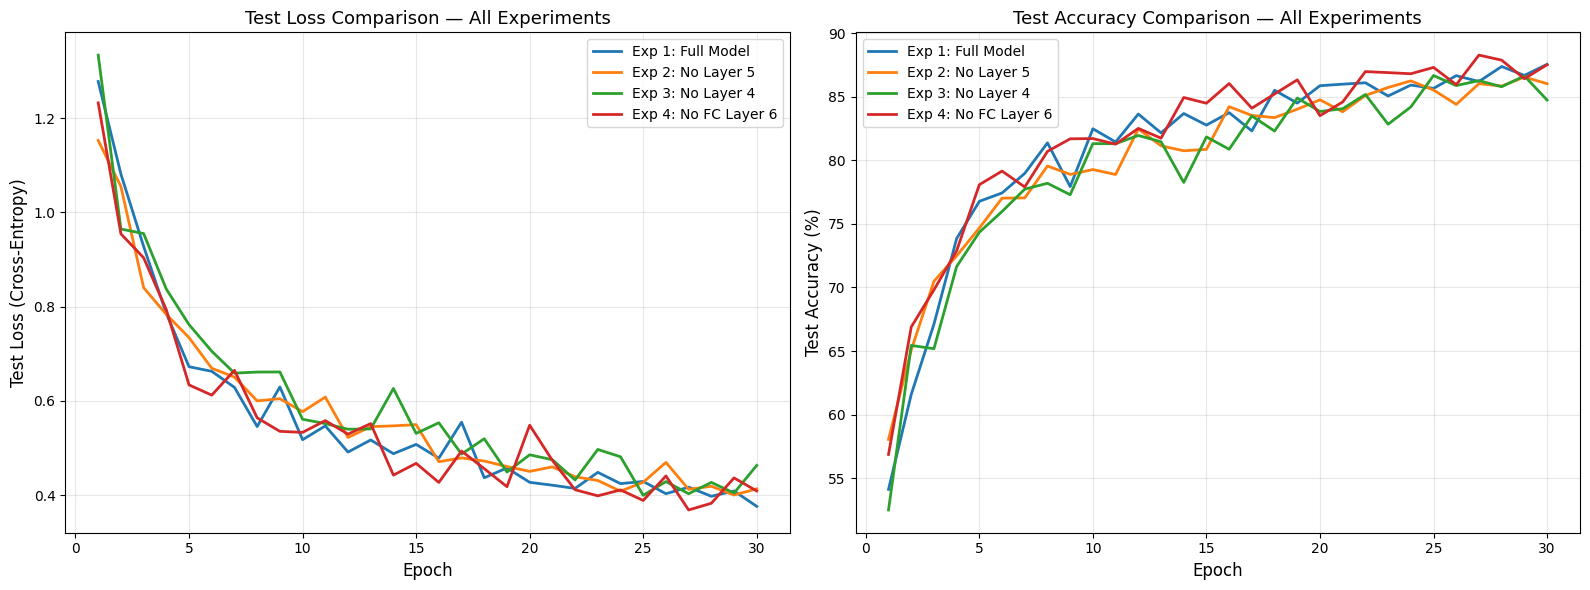

In [19]:
# Overlay all learning curves for comparison
experiments = {
    'Exp 1: Full Model': history_1,
    'Exp 2: No Layer 5': history_2,
    'Exp 3: No Layer 4': history_3,
    'Exp 4: No FC Layer 6': history_4,
}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for (name, hist), color in zip(experiments.items(), colors):
    epochs = range(1, len(hist['test_losses']) + 1)
    ax1.plot(epochs, hist['test_losses'], linewidth=2, label=name, color=color)
    ax2.plot(epochs, hist['test_accs'], linewidth=2, label=name, color=color)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Test Loss (Cross-Entropy)', fontsize=12)
ax1.set_title('Test Loss Comparison — All Experiments', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Test Accuracy Comparison — All Experiments', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

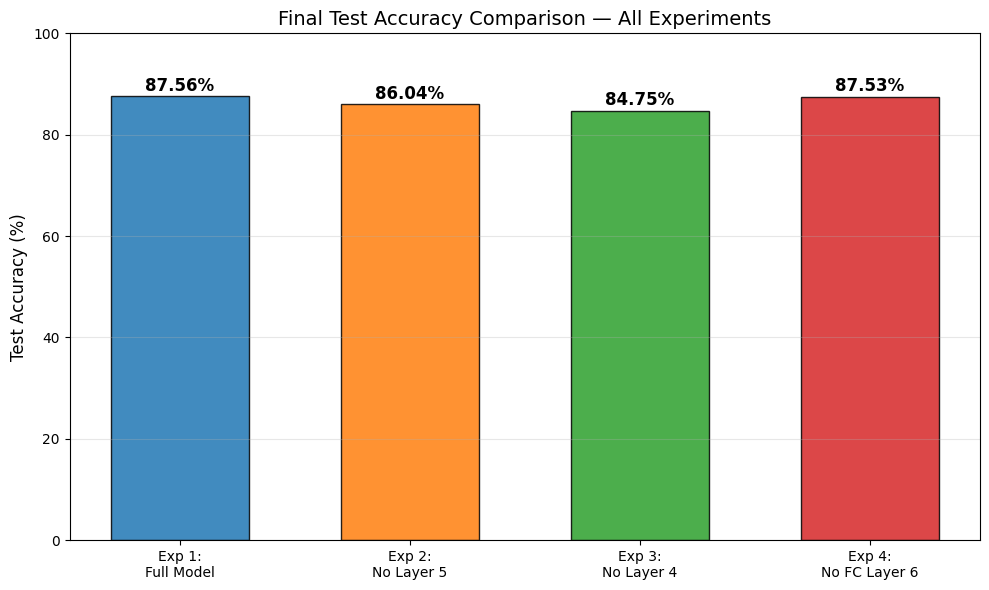


Experiment                       Test Accuracy      Parameters
Exp 1: Full Model                       87.56%      3,216,714
Exp 2: No Layer 5                       86.04%      6,967,882
Exp 3: No Layer 4                       84.75%      2,884,362
Exp 4: No FC Layer 6                    87.53%      2,036,554


In [20]:
# Summary bar chart of final test accuracies
exp_names = ['Exp 1:\nFull Model', 'Exp 2:\nNo Layer 5', 'Exp 3:\nNo Layer 4', 'Exp 4:\nNo FC Layer 6']
accuracies = [acc_1, acc_2, acc_3, acc_4]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(exp_names, accuracies, color=colors, edgecolor='black', alpha=0.85, width=0.6)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Test Accuracy Comparison — All Experiments', fontsize=14)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Experiment':<30} {'Test Accuracy':>15} {'Parameters':>15}")
print("=" * 62)
models_list = [
    ("Exp 1: Full Model", acc_1, AlexNetLike_Full()),
    ("Exp 2: No Layer 5", acc_2, AlexNetLike_NoLayer5()),
    ("Exp 3: No Layer 4", acc_3, AlexNetLike_NoLayer4()),
    ("Exp 4: No FC Layer 6", acc_4, AlexNetLike_NoFC6()),
]
for name, acc, m in models_list:
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<30} {acc:>14.2f}% {n_params:>14,}")

## Summary & Conclusions

In this assignment we built an AlexNet-like CNN for CIFAR-10 classification and performed ablation studies by systematically removing individual layers:

### Key Findings

1. **Experiment 1 (Full Model) — 87.56%:** The complete 5-conv + 2-FC architecture serves as our baseline. It achieves the highest test accuracy, demonstrating that all layers contribute positively to the network's overall performance.

2. **Experiment 2 (No Layer 5 — Conv-256 + Pool) — 86.04% (−1.52%):** Removing the deepest convolutional layer and its pooling resulted in a small accuracy drop. Despite losing the layer responsible for the most abstract, high-level feature representations and the final spatial reduction (8x8→4x4), the remaining layers were still able to compensate reasonably well. The flattened feature vector increased from 4,096 to 12,288 dimensions, putting more burden on the FC layers, but the overall impact was limited.

3. **Experiment 3 (No Layer 4 — Conv-192) — 84.75% (−2.81%):** This removal produced the **largest accuracy drop** of all ablations. Although Layer 4 does not perform pooling or change channel dimensions, it provides a critical additional round of nonlinear feature transformation at 8x8 resolution. Without it, the network jumps directly from 96→192 channel features (Layer 3) to 192→256 features (Layer 5), losing an important intermediate processing stage that refines feature representations before the final convolution.

4. **Experiment 4 (No FC Layer 6 — FC-512) — 87.53% (−0.03%):** Removing the first fully-connected layer had virtually **no impact** on test accuracy, despite eliminating over 2 million parameters. This confirms that the convolutional backbone does the heavy lifting for feature extraction, and a single FC-256 layer is sufficient to learn the 10-class decision boundaries from the already well-separated convolutional features.

### Insights on Layer Importance

- **Convolutional layers** are critical for feature extraction — removing any conv layer reduces the network's ability to build a hierarchical representation of the input.
- **Pooling layers** play a dual role: they reduce spatial dimensions (lowering computation) and provide translation invariance. Losing a pooling stage (as in Exp 2) can be particularly impactful.
- **FC layers** are important for classification but are largely redundant in this architecture — the convolutional features carry most of the discriminative information, and a single FC layer can suffice.
- **Intermediate conv layers** (like Layer 4) can be more important than they appear. Even though Layer 4 doesn't change spatial dimensions or channel count, it provides an extra nonlinear transformation that significantly improves feature quality, as evidenced by the largest accuracy drop when removed.

### Note on Batch Normalization and Accuracy Variance

A key observation is that the accuracy differences across all four experiments are relatively small, ranging from 84.75% to 87.56% (a spread of only ~3%). This is largely attributable to **Batch Normalization (BN)**, which we applied after every convolutional layer.

Batch Normalization (Ioffe & Szegedy, 2015) normalizes the activations within each layer to have zero mean and unit variance during training. This has several effects that compress the performance gap between architectures:

- **Training stability:** BN smooths the loss landscape, making optimization easier even for shallower or less expressive networks. The ablated models converge reliably because BN prevents the internal covariate shift that would otherwise destabilize training when layers are removed.
- **Implicit regularization:** BN introduces noise through mini-batch statistics, which acts as a regularizer. This helps all variants generalize well, even with different capacities.
- **Compensatory learning:** With BN, the remaining layers in each ablated model can more effectively adapt to compensate for the missing layer, since their inputs are always well-conditioned.

It is worth noting that the original AlexNet (Krizhevsky et al., 2012) predates Batch Normalization by three years and instead used Local Response Normalization (LRN), which is far less effective. Without BN, the accuracy gaps between experiments would likely be significantly larger (estimated ~5–7%), as the ablated models would struggle more with training instability and convergence. BN is a standard modern improvement that we applied here to follow current best practices, but it does compress the differences observed in this ablation study.

### Hyperparameters Used Across All Experiments
- **Optimizer:** Adam (LR = 0.001)
- **Loss:** CrossEntropyLoss
- **Batch size:** 128
- **Epochs:** 30
- **Activation:** ReLU (all layers)
- **Regularization:** Dropout 0.5 (FC layers), Batch Normalization (conv layers), Data Augmentation (random flip + crop)